# Домашнее задание «Работа со сложными данными»

## 1. Загрузка и первичный анализ датасета

Используйте текстовый датасет с бинарной разметкой из практического ноутбука занятия (SMS Spam Collection).

1. Загрузите датасет.
2. Убедитесь, что в данных есть столбец с текстом и столбец с бинарной меткой класса (например, «spam» / «ham»).
3. Выведите 5–10 примеров текстов с метками классов.
4. Постройте диаграмму распределения классов (например, столбчатую диаграмму).
Кратко прокомментируйте:
    * как распределены классы;
    * есть ли в текстах шум, сокращения, опечатки, служебные символы и другие особенности.

In [ ]:
import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
    )
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip

--2026-09-18 07:02:27--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip’

smsspamcollection.z     [  <=>               ] 198.65K   444KB/s    in 0.4s    

2026-09-18 07:02:28 (444 KB/s) - ‘smsspamcollection.zip’ saved [203415]



In [ ]:
!unzip smsspamcollection.zip

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [ ]:
df = pd.read_table(
    'SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label','sms_message']
    )
df.head()

,label,sms_message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


*В данных есть столбец с текстом и столбец с бинарной меткой класса «spam» / «ham»*

In [ ]:
pd.set_option('display.max_colwidth', None)

ham_examples = df[df['label'] == 'ham'].sample(5, random_state=42)
spam_examples = df[df['label'] == 'spam'].sample(5, random_state=42)

examples = pd.concat([ham_examples, spam_examples])

print('Примеры текстов с метками классов\n')
display(examples[['label', 'sms_message']])

Примеры текстов с метками классов



,label,sms_message
3714,ham,If i not meeting ü all rite then i'll go home lor. If ü dun feel like comin it's ok.
1311,ham,"I.ll always be there, even if its just in spirit. I.ll get a bb soon. Just trying to be sure i need it."
548,ham,"Sorry that took so long, omw now"
1324,ham,I thk 50 shd be ok he said plus minus 10.. Did ü leave a line in between paragraphs?
3184,ham,Dunno i juz askin cos i got a card got 20% off 4 a salon called hair sense so i tot it's da one ü cut ur hair.
1456,spam,Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 2 Join. OptOut txt STOP Help08714742804
1853,spam,"This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. 2 claim is easy, call 08718726970 NOW! Only 10p per min. BT-national-rate"
673,spam,Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week just £1.50 per wk 2 opt out send STOP 08452810071 16
947,spam,Ur cash-balance is currently 500 pounds - to maximize ur cash-in now send GO to 86688 only 150p/msg. CC: 08718720201 PO BOX 114/14 TCR/W1
2881,spam,"Last Chance! Claim ur £150 worth of discount vouchers today! Text SHOP to 85023 now! SavaMob, offers mobile! T Cs SavaMob POBOX84, M263UZ. £3.00 Sub. 16"


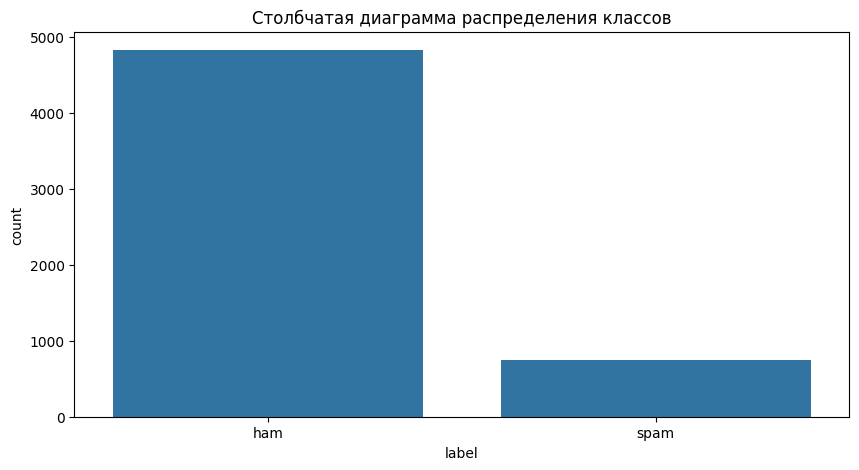

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(x='label', data=df)

plt.title('Столбчатая диаграмма распределения классов')
plt.show()

Наблюдается сильный дисбаланс классов в пользу обычных сообщений: ham — 4825 сообщений, spam — 747.

В текстах много особенностей, характерных для SMS: сокращения (u, thk, shd и прочие), разговорные формы, опечатки, нестандартное написание слов, цифры, символы валют, номера телефонов и служебные конструкции вроде STOP, FREE, NOW. Поэтому перед векторизацией текстам потребуется предобработка.

## 2. Токенизация и базовая статистика

1. Выберите 3–5 предложений из датасета.
2. Выполните токенизацию.
3. Для каждого предложения посчитайте:
    * количество токенов;
    * количество типов;
    * количество лексем.
4. Представьте результаты в виде таблицы.
Кратко прокомментируйте:
    * чем отличаются токены, типы и лексемы;
    * как нормализация влияет на представление текста.

In [ ]:
text_examples = examples.sample(5, random_state=42)

print('Набор случайных 5 текстов из датасета\n')
text_examples

Набор случайных 5 текстов из датасета



,label,sms_message
947,spam,Ur cash-balance is currently 500 pounds - to maximize ur cash-in now send GO to 86688 only 150p/msg. CC: 08718720201 PO BOX 114/14 TCR/W1
1311,ham,"I.ll always be there, even if its just in spirit. I.ll get a bb soon. Just trying to be sure i need it."
1456,spam,Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 2 Join. OptOut txt STOP Help08714742804
3714,ham,If i not meeting ü all rite then i'll go home lor. If ü dun feel like comin it's ok.
673,spam,Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week just £1.50 per wk 2 opt out send STOP 08452810071 16


In [ ]:
# подсчет количеств токенов/типов/уникальных лексем и вывод результата в виде таблицы
lemmatizer = WordNetLemmatizer()

token_stats = []

for text in text_examples['sms_message'].tolist():
    tokens = word_tokenize(text)
    types = set(tokens)
    lemmas = set([lemmatizer.lemmatize(token.lower()) for token in tokens])

    token_stats.append({
        'text': text,
        'tokens_count': len(tokens),
        'types_count': len(types),
        'unique_lemmas_count': len(lemmas)
    })

tokens_stats_df = pd.DataFrame(token_stats)

pd.reset_option('display.max_colwidth')
print('Количество токенов, типов и уникальных лексем в выбранных SMS-сообщениях\n')
display(tokens_stats_df)

Количество токенов, типов и уникальных лексем в выбранных SMS-сообщениях



,text,tokens_count,types_count,unique_lemmas_count
0,Ur cash-balance is currently 500 pounds - to m...,26,25,24
1,"I.ll always be there, even if its just in spir...",27,23,21
2,Summers finally here! Fancy a chat or flirt wi...,33,32,31
3,If i not meeting ü all rite then i'll go home ...,24,20,20
4,Get ur 1st RINGTONE FREE NOW! Reply to this ms...,34,33,32


* Токен - это отдельная единица текста после токенизации (слово, число, фраза, символ и т.п.); тип - уникальный токен, лексема - словарная единица, которая объединяет разные формы одного слова.
* Нормализация приводит разные формы слов к более единому представлению, уменьшает их разнообразие и таким образом делает текст более удобным для последующей обработки и обучения модели.

## 3. Очистка текста и анализ изменений

1. Выполните базовую предобработку текста:
    * приведение к нижнему регистру;
    * удаление пунктуации;
    * удаление стоп-слов;
    * при необходимости — лемматизация.
2. Для не менее чем 100 документов посчитайте длину текста в токенах до и после очистки.
Кратко прокомментируйте:
    * насколько изменилась длина текстов;
    * как предобработка может повлиять на словарь признаков и обучение модели.

*Лемматизация не применялась, так как для данной задачи базовой предобработки достаточно, плюс лемматизация уменьшит словарь, объединяя формы слов, а у коротких SMS отдельные формы могут быть сами по себе информативны.*

In [ ]:
# создание столбцов очищенного текста и длин в токенах
df['cleaned_sms_message'] = df['sms_message']
df['dirty_text_tokens_cnt'] = 0
df['cleaned_text_tokens_cnt'] = 0

# список стоп-слов и частей английских сокращений
stop_words = stopwords.words('english')
contraction_parts = ["'ll", "'ve", "'re", "'d", "'m", "'s", "n't"]

for i in range(len(df)):
    # приведение к нижнему регистру
    text = df.loc[i, 'sms_message'].lower()

    # фиксация длины исходного текста в токенах
    df.loc[i, 'dirty_text_tokens_cnt'] = len(word_tokenize(text))

    # удаление пунктуации с сохранением дефисов и апострофов внутри слов
    text = re.sub(r"(?<!\w)['-]|['-](?!\w)|[^\w\s'-]", ' ', text)

    # удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    # токенизация
    tokens = word_tokenize(text)

    # удаление стоп-слов и частей английских сокращений
    tokens = [
        token for token in tokens
        if (token not in stop_words)
        and (token not in contraction_parts)
        ]

    # склейка токенов в очищенный текст
    text = ' '.join(tokens)

    # фиксация длины очищенного текста в токенах
    df.loc[i, 'cleaned_text_tokens_cnt'] = len(tokens)

    # запись очищенного текста в соотвествующий столбец
    df.loc[i, 'cleaned_sms_message'] = text

print('Результат предобработки SMS и изменение длины текста в токенах')
display(df)

Результат предобработки SMS и изменение длины текста в токенах


,label,sms_message,cleaned_sms_message,dirty_text_tokens_cnt,cleaned_text_tokens_cnt
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,24,16
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,8,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,36,25
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say,13,9
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though,15,7
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,2nd time tried 2 contact u u 750 pound prize 2...,35,20
5568,ham,Will ü b going to esplanade fr home?,ü b going esplanade fr home,9,6
5569,ham,"Pity, * was in mood for that. So...any other s...",pity mood suggestions,15,3
5570,ham,The guy did some bitching but I acted like i'd...,guy bitching acted like interested buying some...,27,13


In [ ]:
# анализ изменения длин текстов
diff = df['cleaned_text_tokens_cnt'].mean() - df['dirty_text_tokens_cnt'].mean()

print(f'Средняя длина текста в токенах до очистки: '
    f'{round(df['dirty_text_tokens_cnt'].mean(), 0)}')
print(f'Средняя длина текста в токенах после очистки: '
    f'{round(df['cleaned_text_tokens_cnt'].mean(), 0)}')
print(f'Изменение длины текста после очистки: {round(diff, 0)}')
print(f'Изменение длины текста в % после очистки: '
    f'{round((abs(diff)/df['dirty_text_tokens_cnt'].mean()) * 100, 0)}')

Средняя длина текста в токенах до очистки: 19.0
Средняя длина текста в токенах после очистки: 10.0
Изменение длины текста после очистки: -9.0
Изменение длины текста в % после очистки: 49.0


* После предобработки средняя длина текста уменьшилась на 9 токенов, или примерно на 49%
* Предобработка сокращает словарь признаков за счет удаления малополезных элементов текста, что может упростить обучение модели.

## 4. Векторизация текста

1. Сформируйте корпус из 10–15 документов.
2. Примените к нему CountVectorizer.
3. Примените к тому же корпусу TF-IDF.
4. Для одного и того же документа покажите и сравните оба вектора.
5. При необходимости оформите сравнение в виде таблицы.
Кратко прокомментируйте:
    * в чём разница между CountVectorizer и TF-IDF;
    * какие слова получают больший вес в TF-IDF и почему;
    * какой из подходов лучше подходит для вашей задачи и по какой причине.

In [ ]:
# формирование корпуса документов
ham_examples = df[df['label'] == 'ham'].sample(7, random_state=42)
spam_examples = df[df['label'] == 'spam'].sample(7, random_state=42)
examples = pd.concat([ham_examples, spam_examples])

corpus = examples['cleaned_sms_message'].tolist()
corpus

['meeting ü rite go home lor ü dun feel like comin ok',
 'always even spirit get bb soon trying sure need',
 'sorry took long omw',
 'thk 50 shd ok said plus minus 10 ü leave line paragraphs',
 'dunno juz askin cos got card got 20 4 salon called hair sense tot da one ü cut ur hair',
 'aight ill get fb couple minutes',
 'somewhere beneath pale moon light someone think u dreams come true goodnite amp sweet dreams',
 'summers finally fancy chat flirt sexy singles yr area get matched reply summer free 2 join optout txt stop help08714742804',
 '2nd time tried 2 contact u u 750 pound prize 2 claim easy call 08718726970 10p per min bt-national-rate',
 'get ur 1st ringtone free reply msg tone gr8 top 20 tones phone every week 1 50 per wk 2 opt send stop 08452810071 16',
 'ur cash-balance currently 500 pounds maximize ur cash-in send go 86688 150p msg cc 08718720201 po box 114 14 tcr w1',
 'last chance claim ur 150 worth discount vouchers today text shop 85023 savamob offers mobile cs savamob p

In [ ]:
# CountVectorizer
count_vectorizer = CountVectorizer()
X_cv = count_vectorizer.fit_transform(corpus)

print(count_vectorizer.get_feature_names_out())
print(X_cv.toarray())

['00' '08452810071' '08712405022' '08718720201' '08718726970' '10' '10p'
 '114' '1146' '14' '150' '150p' '16' '1st' '1x150p' '20' '250' '2nd' '2wt'
 '50' '500' '750' '80608' '85023' '86688' 'action' 'aight' 'always' 'amp'
 'area' 'askin' 'balance' 'bb' 'beneath' 'box' 'bt' 'call' 'called' 'card'
 'cash' 'cc' 'chance' 'chat' 'claim' 'club' 'com' 'come' 'comin' 'contact'
 'cos' 'cost' 'couple' 'cs' 'currently' 'custcare' 'cut' 'da' 'discount'
 'dreams' 'dun' 'dunno' 'easy' 'enjoy' 'even' 'every' 'fancy' 'fb' 'feel'
 'finally' 'flirt' 'free' 'gbp4' 'get' 'go' 'goodnite' 'got' 'gr8' 'hair'
 'help08714742804' 'home' 'html' 'ill' 'in' 'join' 'juz' 'last' 'leave'
 'light' 'like' 'line' 'long' 'lor' 'm263uz' 'matched' 'maximize'
 'meeting' 'mfl' 'min' 'minus' 'minutes' 'mix' 'mk45' 'mobile' 'moon'
 'movietrivia' 'msg' 'my' 'national' 'need' 'offers' 'ok' 'omw' 'one'
 'opt' 'optout' 'pale' 'paragraphs' 'per' 'phone' 'plus' 'po' 'pobox84'
 'pound' 'pounds' 'prize' 'rate' 'reply' 'replying' 'ring

In [ ]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tf = tfidf_vectorizer.fit_transform(corpus)

print(tfidf_vectorizer.get_feature_names_out())
print(X_tf.toarray())

['00' '08452810071' '08712405022' '08718720201' '08718726970' '10' '10p'
 '114' '1146' '14' '150' '150p' '16' '1st' '1x150p' '20' '250' '2nd' '2wt'
 '50' '500' '750' '80608' '85023' '86688' 'action' 'aight' 'always' 'amp'
 'area' 'askin' 'balance' 'bb' 'beneath' 'box' 'bt' 'call' 'called' 'card'
 'cash' 'cc' 'chance' 'chat' 'claim' 'club' 'com' 'come' 'comin' 'contact'
 'cos' 'cost' 'couple' 'cs' 'currently' 'custcare' 'cut' 'da' 'discount'
 'dreams' 'dun' 'dunno' 'easy' 'enjoy' 'even' 'every' 'fancy' 'fb' 'feel'
 'finally' 'flirt' 'free' 'gbp4' 'get' 'go' 'goodnite' 'got' 'gr8' 'hair'
 'help08714742804' 'home' 'html' 'ill' 'in' 'join' 'juz' 'last' 'leave'
 'light' 'like' 'line' 'long' 'lor' 'm263uz' 'matched' 'maximize'
 'meeting' 'mfl' 'min' 'minus' 'minutes' 'mix' 'mk45' 'mobile' 'moon'
 'movietrivia' 'msg' 'my' 'national' 'need' 'offers' 'ok' 'omw' 'one'
 'opt' 'optout' 'pale' 'paragraphs' 'per' 'phone' 'plus' 'po' 'pobox84'
 'pound' 'pounds' 'prize' 'rate' 'reply' 'replying' 'ring

In [ ]:
vectorizer_comparison_df = pd.DataFrame({
    'Word': count_vectorizer.get_feature_names_out(),
    'CountVectorizer': X_cv.toarray()[0],
    'TF-IDF': X_tf.toarray()[0]
})

vectorizer_comparison_df = vectorizer_comparison_df[
    vectorizer_comparison_df['CountVectorizer'] > 0
    ]

print('Сравнение векторов одного SMS с помощью CountVectorizer и TF-IDF')
display(vectorizer_comparison_df)

Сравнение векторов одного SMS с помощью CountVectorizer и TF-IDF


,Word,CountVectorizer,TF-IDF
47,comin,1,0.324473
59,dun,1,0.324473
67,feel,1,0.324473
73,go,1,0.280836
79,home,1,0.324473
88,like,1,0.324473
91,lor,1,0.324473
95,meeting,1,0.324473
110,ok,1,0.280836
129,rite,1,0.324473


`CountVectorizer` учитывает только частоту слова в конкретном документе, а `TF-IDF` помимо этого ещё учитывает, насколько это слово редко или часто встречается во всём корпусе. В `TF-IDF` слова, которые часто встречаются в конкретном документе, но редко встречаются в других документах корпуса, получают больший вес. Это происходит из-за компоненты `IDF` — обратной частоты документов: чем реже слово встречается по корпусу, тем согласно расчетной формуле выше его `IDF` и, соответственно, итоговый вес `TF-IDF`.

Для задачи классификации SMS на `spam` и `ham` более подходящим является `TF-IDF`, так как он снижает влияние часто встречающихся малоинформативных слов и сильнее выделяет слова, характерные для отдельных сообщений. Это может помочь модели лучше различать классы.

## 5. Обучение модели

1. Разделите данные на обучающую и тестовую выборки.
2. Преобразуйте тексты в TF-IDF-признаки.
3. Обучите наивный байесовский классификатор на задаче бинарной классификации.
4. Рассчитайте метрики качества на тестовой выборке:
    * accuracy;
    * precision;
    * recall;
    * F1-score.
5. Выберите 5 примеров из тестовой выборки и для каждого покажите:
    * исходный текст;
    * истинный класс;
    * предсказанный класс;
    * вероятности предсказания по классам.
6. Кратко прокомментируйте:
    * какие тексты модель определяет уверенно;
    * в каких случаях она ошибается;
    * какие ограничения наивного Байеса проявились в вашей задаче.

In [ ]:
# кодировщик LabelEncoder
le = LabelEncoder().fit(df['label'])
df['cat_label'] = le.transform(df['label'])
df['cat_label'].value_counts()

,count
cat_label,
0,4825
1,747


In [ ]:
# выделение признаков, целевой переменной и разделение данных
X = df['cleaned_sms_message']
y = df['cat_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

# векторизация
tfidf_vectorizer_train = TfidfVectorizer()
X_train_tf = tfidf_vectorizer_train.fit_transform(X_train)
X_test_tf = tfidf_vectorizer_train.transform(X_test)

In [ ]:
# обучение наивного байесовского классификатора
model = MultinomialNB()
model.fit(X_train_tf, y_train)

MultinomialNB()

In [ ]:
# предсказания и расчет метрик на тестовой выборке
y_pred = model.predict(X_test_tf)

print('Метрики качества обученного наивного байесовского классификатора:\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1: {f1_score(y_test, y_pred):.4f}')

Метрики качества обученного наивного байесовского классификатора:

Accuracy: 0.9659
Precision: 1.0000
Recall: 0.7450
F1: 0.8538


In [ ]:
# выбор 5 примеров из тестовой выборки
sample_indices = X_test.sample(5, random_state=42).index
X_sample = X_test.loc[sample_indices]

# TF-IDF признаки выбранных сообщений
X_sample_tf = tfidf_vectorizer_train.transform(X_sample)

# предсказания и вероятности
y_sample_pred = model.predict(X_sample_tf)
y_sample_proba = model.predict_proba(X_sample_tf)

# результаты
examples_results_df = pd.DataFrame({
    'Text': df.loc[sample_indices, 'sms_message'],
    'True class': df.loc[sample_indices, 'label'],
    'Predicted class': le.inverse_transform(y_sample_pred),
    'P(ham)': y_sample_proba[:, 0],
    'P(spam)': y_sample_proba[:, 1]
    })

print('Таблица результатов предсказания для 5 примеров тестовой выборки')
display(examples_results_df)

Таблица результатов предсказания для 5 примеров тестовой выборки


,Text,True class,Predicted class,P(ham),P(spam)
5098,TheMob>Hit the link to get a premium Pink Pant...,spam,ham,0.660945,0.339055
3347,U're welcome... Caught u using broken english ...,ham,ham,0.772025,0.227975
4276,Haiyoh... Maybe your hamster was jealous of mi...,ham,ham,0.904008,0.095992
2564,K..k..i'm also fine:)when will you complete th...,ham,ham,0.986615,0.013385
144,I know you are. Can you pls open the back?,ham,ham,0.989772,0.010228


* Модель уверенно определяет сообщения `ham` (не спам). В отобранных выше примерах вероятность класса `ham` достигает примерно `0.9–0.99`.
* Ошибки возникают на некоторых сообщениях `spam`, которые, видимо, по лексике могут быть на обычные сообщения и не содержат достаточно выраженных признаков спама. Это согласуется с тем, что получен `recall = 0.745`: часть спам-сообщений модель пропускает.
* Ограничение наивного Байеса состоит в предположении условной независимости признаков. В текстах слова на самом деле зависят друг от друга и образуют устойчивые сочетания, поэтому модель не учитывает порядок слов и контекст фразы. Из-за этого некоторые сообщения с неоднозначной лексикой могут классифицироваться ошибочно, что и проявилось в данной задаче.

## 6. Итоговые выводы

В конце работы сформулируйте не менее 5 итоговых тезисов, в которых отразите:
* как предобработка влияет на текстовые данные и признаки;
* в чём различие CountVectorizer и TF-IDF;
* как ведёт себя наивный Байес на текстовой задаче;
* какие ограничения классических моделей проявляются при работе с текстами;
* какие подходы и инструменты оказались наиболее полезными в рамках задания.

* Предобработка уменьшает количество признаков за счет удаления малополезных элементов текста, стоп-слов, частей сокращений и т.д., что может упростить обучение модели.
* `CountVectorizer` учитывает только частоту слова в конкретном документе, а `TF-IDF` дполнительно учитывает, насколько это слово редко или часто встречается во всём корпусе. Поэтому слова, которые часто встречаются в конкретном документе, но редко - в других документах корпуса, получают больший вес. Для данной задачи классификации SMS-сообщений `TF-IDF` является более подходящим, так как он снижает влияние часто встречающихся слов и сильнее выделяет потенциально значимые для разделения `spam` и `ham` признаки.
* В текстовых задачах наивный байес обычно работает быстро и достаточно эффективно на разреженных признаках, особенно когда классы хорошо различаются по частотам слов. В данной задаче наивный байесовский классификатор показал высокое качество: `Accuracy = 0.9659`, `Precision = 1.0`, `Recall = 0.7450`, `F1 = 0.8538`. Модель почти не относит обычные сообщения к спаму; все сообщения, которые модель назвала спамом, действительно были спамом (значение `Precision`), но при этом пропускает часть настоящих спам-сообщений (значение `Recall`).
* Одним из ограничений, причем строгим, наивного Байеса является предположение о независимости признаков. В текстах слова связаны между собой и образуют устойчивые сочетания, а модель не учитывает порядок слов и контекст, поэтому сообщения с неоднозначной лексикой могут классифицироваться ошибочно.
* Наиболее полезными инструментами в работе оказались очистка текста, токенизация, удаление стоп-слов, TF-IDF-векторизация и MultinomialNB, поскольку вместе они позволяют преобразовать неструктурированный текст в числовые признаки и решить задачу бинарной классификации.